![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 02 | Processing and Database Design


**Dataset:** FAOSTAT


---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

import sqlite3
#%pip install eralchemy2
from eralchemy2 import render_er
from IPython.display import Image, display

---
## 1. Load the raw data

In [2]:
fbs_country = pd.read_csv("../data/raw/fbs_country.csv")
fbs_products = pd.read_csv("../data/raw/fbs_products.csv")
qcl_area = pd.read_csv("../data/raw/qcl_area.csv")
gdp_per_capita = pd.read_csv("../data/raw/gdp_per_capita.csv")
df_fao_list_datasets = pd.read_csv("../data/raw/fao_list_datasets.csv")
population = pd.read_csv("../data/raw/population.csv")
fbs_trade = pd.read_csv("../data/raw/fbs_trade.csv")

---
## 2. Clean

Work through the problems.

- Missing values were reviewed.
- Duplicate rows were checked.
- Numeric columns were already stored as numeric types.
- Year values were consistent.
- No obvious invalid records were found.

Therefore, no rows were removed at this stage.

In [3]:
df_fao_list_datasets.rename(columns={"code": "dataset_code"}, inplace=True)

---
## 3. Design your tables

Decide what your tables are and how they relate.

The database will contain 6 tables:

- `datasets`: metadata about FAOSTAT datasets
- `areas`: lookup table for countries/areas
- `fbs_country`: country-level food balance observations
- `fbs_products`: product-level dietary energy observations
- `harvested_area`: total harvested crop area by country and year
- `gdp_per_capita`: GDP per capita by country and year

---
## 4. Build the tables

Split the cleaned data into the tables.

In [4]:
datasets = df_fao_list_datasets.copy()

In [5]:
areas = pd.concat([
    fbs_country[["Area Code", "Area"]],
    fbs_products[["Area Code", "Area"]],
    qcl_area[["Area Code", "Area"]],
    gdp_per_capita[["Area Code", "Area"]],
    population[["Area Code", "Area"]],
    fbs_trade[["Area Code", "Area"]]
])

areas = (
    areas
    .drop_duplicates()
    .rename(columns={
        "Area Code": "area_code",
        "Area": "area_name"
    })
    .reset_index(drop=True)
)

In [6]:
fbs_country_table = fbs_country[["Area Code", "Year", "Element Code", "Unit", "Value"]].copy()

fbs_country_table = fbs_country_table.rename(columns={
    "Area Code": "area_code",
    "Year": "year",
    "Element Code": "element_code",
    "Unit": "unit",
    "Value": "value"
})

fbs_country_table["dataset_code"] = "FBS"

In [7]:
fbs_products_table = fbs_products[["Area Code", "Year", "Item Code", "Item", "Unit", "Value"]].copy()

fbs_products_table = fbs_products_table.rename(columns={
    "Area Code": "area_code",
    "Year": "year",
    "Item Code": "item_code",
    "Item": "item_name",
    "Unit": "unit",
    "Value": "value"
})

fbs_products_table["dataset_code"] = "FBS"

In [8]:
harvested_area = (
    qcl_area
    .groupby(["Area Code", "Area", "Year"], as_index=False)["Value"]
    .sum()
    .rename(columns={
        "Area Code": "area_code",
        "Year": "year",
        "Value": "harvested_area_ha"
    })
)

harvested_area = harvested_area[["area_code", "year", "harvested_area_ha"]]

harvested_area["dataset_code"] = "QCL"

In [9]:
gdp_table = gdp_per_capita[["Area Code", "Year", "Value"]].copy()

gdp_table = gdp_table.rename(columns={
    "Area Code": "area_code",
    "Year": "year",
    "Value": "gdp_per_capita"
})

gdp_table["dataset_code"] = "MK"

In [10]:
population_table = population[["Area Code", "Year", "Unit", "Value"]].copy()

population_table = population_table.rename(columns={
    "Area Code": "area_code",
    "Year": "year",
    "Unit": "unit",
    "Value": "population"
})

population_table["dataset_code"] = "OA"

In [11]:
fbs_trade_table = fbs_trade[["Area Code","Year","Item Code","Item","Element Code","Element","Unit","Value"]].copy()

fbs_trade_table = fbs_trade_table.rename(columns={
    "Area Code": "area_code",
    "Year": "year",
    "Item Code": "item_code",
    "Item": "item_name",
    "Element Code": "element_code",
    "Element": "element_name",
    "Unit": "unit",
    "Value": "value"
})

fbs_trade_table["dataset_code"] = "FBS"

In [12]:
tables = {
    "datasets": datasets,
    "areas": areas,
    "fbs_country": fbs_country_table,
    "fbs_products": fbs_products_table,
    "harvested_area": harvested_area,
    "gdp_per_capita": gdp_table,
    "population": population_table,
    "fbs_trade": fbs_trade_table
}

for name, df in tables.items():
    print(name, df.shape)
    display(df.head())

datasets (69, 10)


,dataset_code,label,date_update,note_update,release_current,state_current,year_current,release_next,state_next,year_next
0,QCL,Crops and livestock products,2025-12-31,NaN,2025-12-31,final,2024.0,2026-12,final,2025.0
1,QI,Production Indices,2026-05-11,NaN,2026-05-11,final,2024.0,2027-02,final,2025.0
2,QV,Value of Agricultural Production,2026-05-11,NaN,2026-05-11,final,2024.0,2027-02,final,2025.0
3,FS,Suite of Food Security Indicators,2026-07-21,NaN,2026-07-21,final,2025.0,2027-07,final,2026.0
4,FBS,Food Balances (2010-),2025-10-28,NaN,2025-10-28,final,2023.0,2026-10,final,2024.0


areas (277, 2)


,area_code,area_name
0,2,Afghanistan
1,3,Albania
2,4,Algeria
3,7,Angola
4,8,Antigua and Barbuda


fbs_country (2901, 6)


...

,area_code,year,gdp_per_capita,dataset_code
0,2,1970,936.761736,MK
1,2,1971,911.765484,MK
2,2,1972,743.832418,MK
3,2,1973,746.216093,MK
4,2,1974,767.272660,MK


population (38973, 5)


,area_code,year,unit,population,dataset_code
0,2,1950,1000 No,7776.176,OA
1,2,1951,1000 No,7879.339,OA
2,2,1952,1000 No,7987.783,OA
3,2,1953,1000 No,8096.698,OA
4,2,1954,1000 No,8207.950,OA


fbs_trade (112008, 9)


,area_code,year,item_code,item_name,element_code,element_name,unit,value,dataset_code
0,2,2010,2905,Cereals - Excluding Beer,5511,Production,1000 t,5957,FBS
1,2,2010,2905,Cereals - Excluding Beer,5611,Import quantity,1000 t,2000,FBS
2,2,2011,2905,Cereals - Excluding Beer,5511,Production,1000 t,4681,FBS
3,2,2011,2905,Cereals - Excluding Beer,5611,Import quantity,1000 t,2448,FBS
4,2,2012,2905,Cereals - Excluding Beer,5511,Production,1000 t,6379,FBS


---
## 5. Check the foreign keys


In [13]:
# Area foreign keys

for name, df in {
    "fbs_country": fbs_country_table,
    "fbs_products": fbs_products_table,
    "harvested_area": harvested_area,
    "gdp_per_capita": gdp_table,
    "population": population_table
}.items():

    missing_area_codes = set(df["area_code"]) - set(areas["area_code"])

    print(name, "missing area codes:", missing_area_codes)

fbs_country missing area codes: set()
fbs_products missing area codes: set()
harvested_area missing area codes: set()
gdp_per_capita missing area codes: set()
population missing area codes: set()


In [14]:
for name, df in {
    "fbs_country": fbs_country_table,
    "fbs_products": fbs_products_table,
    "harvested_area": harvested_area,
    "gdp_per_capita": gdp_table,
    "population": population_table
}.items():

    missing_dataset_codes = (set(df["dataset_code"]) - set(datasets["dataset_code"]))

    print(name, "missing dataset codes:", missing_dataset_codes)

fbs_country missing dataset codes: set()
fbs_products missing dataset codes: set()
harvested_area missing dataset codes: set()
gdp_per_capita missing dataset codes: set()
population missing dataset codes: set()


In [15]:
print("Duplicate area codes:",areas["area_code"].duplicated().sum())
print("Duplicate dataset codes:",datasets["dataset_code"].duplicated().sum())

Duplicate area codes: 0
Duplicate dataset codes: 0


---
## 6. Create the database and load it

Write your `CREATE TABLE` statements in `sql/schema.sql`, then load the tables — parents before children, or the foreign keys will be rejected.

In [16]:
DB_PATH = "../data/project.db"
con = sqlite3.connect(DB_PATH)
con.execute("PRAGMA foreign_keys = ON")

In [17]:
with open("../sql/schema.sql", "r") as file:
    schema = file.read()
con.executescript(schema)

In [18]:
datasets.to_sql(
    "datasets",
    con,
    if_exists="append",
    index=False
)

areas.to_sql(
    "areas",
    con,
    if_exists="append",
    index=False
)

fbs_country_table.to_sql(
    "fbs_country",
    con,
    if_exists="append",
    index=False
)

fbs_products_table.to_sql(
    "fbs_products",
    con,
    if_exists="append",
    index=False
)

harvested_area.to_sql(
    "harvested_area",
    con,
    if_exists="append",
    index=False
)

gdp_table.to_sql(
    "gdp_per_capita",
    con,
    if_exists="append",
    index=False
)

population_table.to_sql(
    "population",
    con,
    if_exists="append",
    index=False
)

fbs_trade_table.to_sql(
    "fbs_trade",
    con,
    if_exists="append",
    index=False
)


112008

---
## 7. Verify

Row counts per table, and one join that returns the rows you expect. Then open `data/project.db` in DB Browser and look at it.

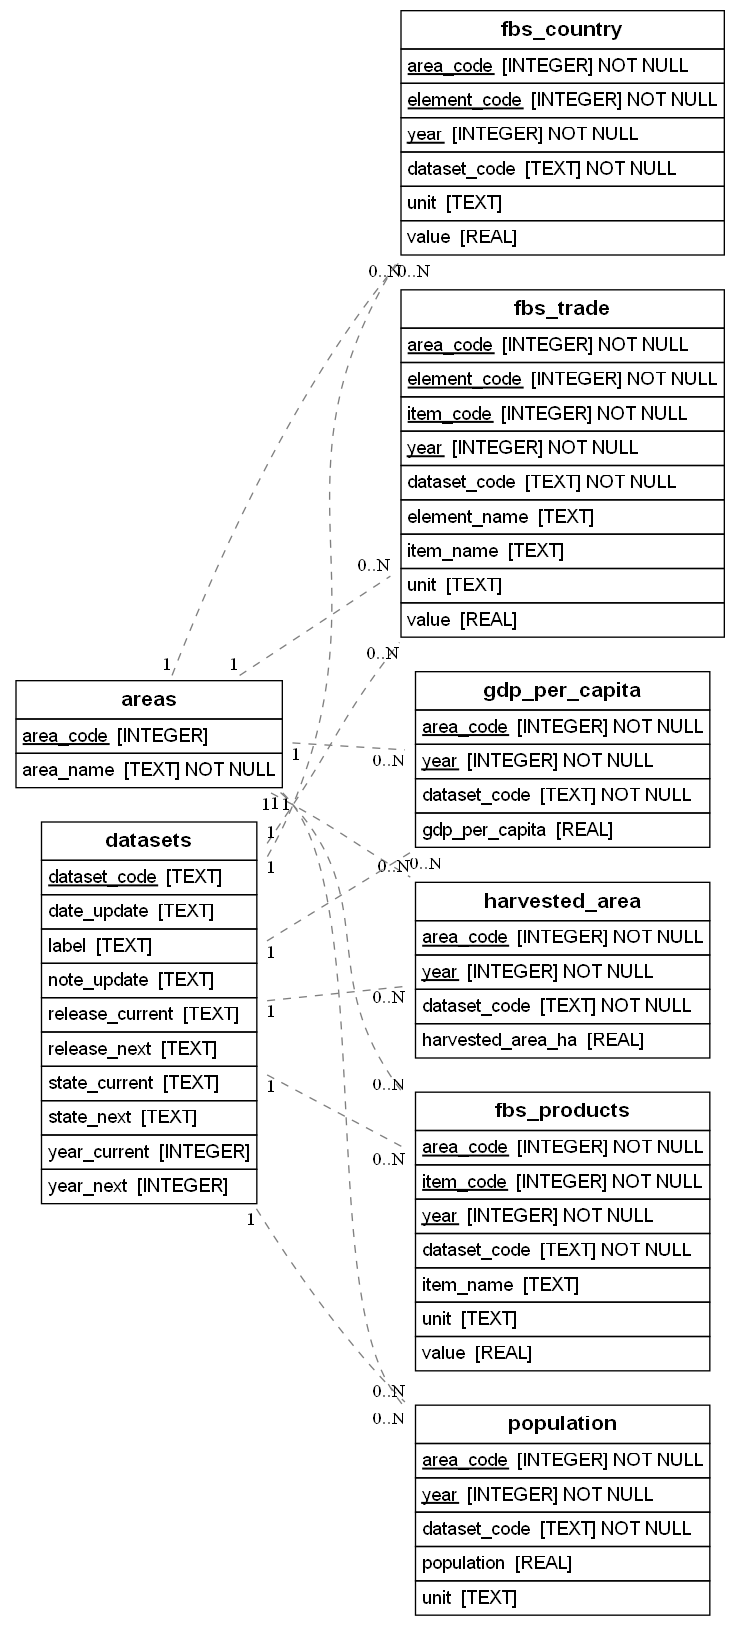

In [19]:
# eralchemy2 to draw an ERD
#%pip install eralchemy2
from eralchemy2 import render_er
from IPython.display import Image, display
render_er("sqlite:///../data/project.db","../data/erd.png")
display(Image(filename="../data/erd.png"))

In [20]:
# No of rows per table

tables = [
    "datasets",
    "areas",
    "fbs_country",
    "fbs_products",
    "harvested_area",
    "gdp_per_capita",
    "population",
    "fbs_trade"
]

for table in tables:
    count = con.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]

    print(table, count)

datasets 69
areas 277
fbs_country 2901
fbs_products 310263
harvested_area 14215
gdp_per_capita 12697
population 38973
fbs_trade 112008


In [21]:
# Tables in the database (sqlite_master)

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
""", con)

display(tables)

,name
0,areas
1,datasets
2,fbs_country
3,fbs_products
4,fbs_trade
5,gdp_per_capita
6,harvested_area
7,population


In [22]:
# PRAGMA table_info()
# pk number = position of a column inside the primary key

for table in tables["name"]:
    print(f"TABLE: {table}")
    display(
        pd.read_sql(f"PRAGMA table_info({table});", con)
    )

TABLE: areas


,cid,name,type,notnull,dflt_value,pk
0,0,area_code,INTEGER,0,None,1
1,1,area_name,TEXT,1,None,0


TABLE: datasets


,cid,name,type,notnull,dflt_value,pk
0,0,dataset_code,TEXT,0,None,1
1,1,label,TEXT,0,None,0
2,2,date_update,TEXT,0,None,0
3,3,note_update,TEXT,0,None,0
4,4,release_current,TEXT,0,None,0
5,5,state_current,TEXT,0,None,0
6,6,year_current,INTEGER,0,None,0
7,7,release_next,TEXT,0,None,0
8,8,state_next,TEXT,0,None,0
9,9,year_next,INTEGER,0,None,0


TABLE: fbs_country


...

,cid,name,type,notnull,dflt_value,pk
0,0,dataset_code,TEXT,1,None,0
1,1,area_code,INTEGER,1,None,1
2,2,year,INTEGER,1,None,2
3,3,gdp_per_capita,REAL,0,None,0


TABLE: harvested_area


,cid,name,type,notnull,dflt_value,pk
0,0,dataset_code,TEXT,1,None,0
1,1,area_code,INTEGER,1,None,1
2,2,year,INTEGER,1,None,2
3,3,harvested_area_ha,REAL,0,None,0


TABLE: population


,cid,name,type,notnull,dflt_value,pk
0,0,dataset_code,TEXT,1,None,0
1,1,area_code,INTEGER,1,None,1
2,2,year,INTEGER,1,None,2
3,3,unit,TEXT,0,None,0
4,4,population,REAL,0,None,0


In [23]:
# PRAGMA foreign_key_list

for table in tables["name"]:
    print(f"\nFOREIGN KEYS: {table}")
    display(
        pd.read_sql(f"PRAGMA foreign_key_list({table});", con)
    )


FOREIGN KEYS: areas


,id,seq,table,from,to,on_update,on_delete,match



FOREIGN KEYS: datasets


,id,seq,table,from,to,on_update,on_delete,match



FOREIGN KEYS: fbs_country


...

,id,seq,table,from,to,on_update,on_delete,match
0,0,0,areas,area_code,area_code,NO ACTION,NO ACTION,NONE
1,1,0,datasets,dataset_code,dataset_code,NO ACTION,NO ACTION,NONE



FOREIGN KEYS: harvested_area


,id,seq,table,from,to,on_update,on_delete,match
0,0,0,areas,area_code,area_code,NO ACTION,NO ACTION,NONE
1,1,0,datasets,dataset_code,dataset_code,NO ACTION,NO ACTION,NONE



FOREIGN KEYS: population


,id,seq,table,from,to,on_update,on_delete,match
0,0,0,areas,area_code,area_code,NO ACTION,NO ACTION,NONE
1,1,0,datasets,dataset_code,dataset_code,NO ACTION,NO ACTION,NONE
